# 전류 보존 검증 — 반지름 슬라이더 인터랙티브 도구

전극 근처에 그린 폐곡선(원)의 반지름을 슬라이더로 움직이면:
- 그 폐곡선 위에 있는 전기장 화살표만 **분홍색**으로 강조
- 강조된 화살표들을 각도에 대해 적분(flux) → **그 반지름에서의 전류값**을 실시간으로 계산/표시

$$\Phi(r) = \oint E_r(\theta)\, r\, d\theta \;\approx\; \text{const.}$$

**필요 패키지**: `pip install ipympl ipywidgets` (실시간 반응을 위해 `%matplotlib widget` 백엔드 사용 — 안 되면 `%matplotlib notebook`으로 대체 시도, 둘 다 안 되면 이 노트북 대신 같은 폴더의 `efield_flux_slider_tool.m` MATLAB 버전을 쓰세요.)

데이터 로딩 함수(`load_leadfield_2d`)와 전극 좌표(`ELECTRODE_XY_TABLE`)는 `efield_analysis.ipynb`의 정의를 그대로 가져옵니다 — 전극 위치를 argmax로 추정하지 않고, 실측 geometry 표를 그대로 씁니다.

**주의**: 화살표는 CSV의 모든 노드를 그립니다(서브샘플링 없음) — 노드 수가 많으면 렌더링이 느릴 수 있습니다.


In [20]:
pip install ipywidgets ipympl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display

try:
    get_ipython().run_line_magic('matplotlib', 'widget')
except Exception as e:
    print(f"[!] ipympl(widget 백엔드) 로드 실패 — 정적 갱신으로 대체됩니다: {e}")


In [22]:
def load_leadfield_2d(filepath, x_range=None, y_range=None):
    """
    COMSOL 2D lead field CSV 로드 (efield_analysis.ipynb와 동일).
    반환: coords (N, 2), E_tensor (num_electrodes, N, 2)
    """
    df = pd.read_csv(filepath, comment='%', header=None)
    df = df.dropna().reset_index(drop=True)

    cx = df.iloc[:, 0].values.astype(float)
    cy = df.iloc[:, 1].values.astype(float)

    if x_range is None:
        x_range = (float(cx.min()), float(cx.max()))
    if y_range is None:
        y_range = (float(cy.min()), float(cy.max()))

    mask = (cx >= x_range[0]) & (cx <= x_range[1]) & (cy >= y_range[0]) & (cy <= y_range[1])
    df = df[mask].reset_index(drop=True)

    coords = df.iloc[:, :2].values.astype(float)
    field_cols = df.iloc[:, 2:]
    num_electrodes = field_cols.shape[1] // 2
    num_points = len(df)

    parsed = np.zeros((num_points, field_cols.shape[1]), dtype=np.float64)
    for i in range(field_cols.shape[1]):
        col_str = (field_cols.iloc[:, i]
                   .fillna('0').astype(str)
                   .str.replace(' ', '', regex=False)
                   .str.replace('i', 'j', regex=False))
        parsed[:, i] = np.real(np.array([complex(v) for v in col_str]))

    E_tensor = np.zeros((num_electrodes, num_points, 2))
    for e in range(num_electrodes):
        E_tensor[e, :, 0] = parsed[:, e * 2]
        E_tensor[e, :, 1] = parsed[:, e * 2 + 1]

    return coords, E_tensor


# ── 경로 설정 (efield_analysis.ipynb와 동일 규칙 — 조건 바꿀 때 이 부분만 수정) ──
SIM_DIR = Path(r"D:\00_Project\nTIS\docs\07_Simulation\Result")
BASE_NAME = "COMSOL_Efield_CompactY_X50_Y10"
LEADFIELD_F1 = SIM_DIR / f"{BASE_NAME}_leadField_f1.csv"   # 왼쪽 두 전극(전극1,2 = CH1 pair)

coords, E_f1 = load_leadfield_2d(LEADFIELD_F1)
x, y = coords[:, 0], coords[:, 1]
print(f"노드 수: {len(coords)},  x:[{x.min():.1f},{x.max():.1f}]mm  y:[{y.min():.1f},{y.max():.1f}]mm")

E1_single = E_f1[0]                 # 전극1(CH1 top) 단독 필드
E2_single = E_f1[1]                 # 전극2(CH1 bot) 단독 필드
Ef1 = E_f1[0] - E_f1[1]             # 채널(다이폴) 합성 필드 — 시각화 기본값
E_mag = np.linalg.norm(Ef1, axis=1)


노드 수: 451,  x:[-25.0,25.0]mm  y:[-5.0,5.0]mm


## 전극 좌표 — efield_analysis.ipynb 4번 셀과 동일한 실측 geometry 사용

argmax로 추정하지 않고, `ELECTRODE_XY_TABLE`(팬텀 크기별 실측 전극 좌표)에서 정확한 좌표를 가져온다.


In [23]:
ELECTRODE_XY_TABLE = {
    (50, 50): (25, 20),
    (30, 50): (15, 20),
    (10, 50): (5, 20),
    (50, 30): (20, 15),
    (50, 10): (20, 5),
    (30, 30): (15, 10),
    (10, 10): (5, 2.5),
}

_xy_match = re.search(r"X(\d+)_Y(\d+)$", BASE_NAME)
if _xy_match is None:
    raise ValueError(f"BASE_NAME '{BASE_NAME}'에서 X##_Y## 패턴을 찾을 수 없습니다.")
PHANTOM_X_MM, PHANTOM_Y_MM = int(_xy_match.group(1)), int(_xy_match.group(2))

if (PHANTOM_X_MM, PHANTOM_Y_MM) not in ELECTRODE_XY_TABLE:
    raise KeyError(f"팬텀 크기 ({PHANTOM_X_MM}, {PHANTOM_Y_MM})에 대한 전극 좌표가 없습니다.")
_ex, _ey = ELECTRODE_XY_TABLE[(PHANTOM_X_MM, PHANTOM_Y_MM)]

ELECTRODES = {
    "CH1 top": (-_ex,  _ey),
    "CH1 bot": (-_ex, -_ey),
    "CH2 top": (_ex,  _ey),
    "CH2 bot": (_ex, -_ey),
}

elec1_xy = np.array(ELECTRODES["CH1 top"])   # E_f1[0] = 전극1 = CH1 top
elec2_xy = np.array(ELECTRODES["CH1 bot"])   # E_f1[1] = 전극2 = CH1 bot
elec_dist = np.hypot(*(elec2_xy - elec1_xy))
print(f"전극1(CH1 top): {elec1_xy} mm,  전극2(CH1 bot): {elec2_xy} mm,  전극간 거리: {elec_dist:.2f} mm")


전극1(CH1 top): [-20   5] mm,  전극2(CH1 bot): [-20  -5] mm,  전극간 거리: 10.00 mm


In [24]:
# 화살표는 CSV의 모든 노드에 대해 그린다 (서브샘플링 없음)
coords_sub = coords
Ef1_sub = Ef1
Emag_sub = E_mag

CENTER = elec1_xy   # 폐곡선(원) 기준 = 전극1(CH1 top)
dx_sub = coords_sub[:, 0] - CENTER[0]
dy_sub = coords_sub[:, 1] - CENTER[1]
r_sub = np.hypot(dx_sub, dy_sub)
theta_sub = np.arctan2(dy_sub, dx_sub)

R_MIN = max(1.0, elec_dist * 0.05)
R_MAX = elec_dist * 0.9   # 전극2를 감싸지 않도록 제한 (폐곡선 안에 전극1만 들어가게)
print(f"슬라이더 반지름 범위: [{R_MIN:.2f}, {R_MAX:.2f}] mm")


슬라이더 반지름 범위: [1.00, 9.00] mm


## flux(전류) 계산 함수

annulus(반지름 r ± dr) 안의 점들을 각도로 정렬 → 반지름 방향 성분 적분.


In [25]:
_trapz = getattr(np, "trapezoid", None) or np.trapz   # numpy>=2.0 호환 (trapz -> trapezoid)


def compute_flux(r_target, dr=0.8):
    mask = (r_sub >= r_target - dr / 2) & (r_sub <= r_target + dr / 2)
    n = mask.sum()
    if n < 3:
        return 0.0, mask
    th = theta_sub[mask]
    order = np.argsort(th)
    th_sorted = th[order]

    nx = np.cos(th_sorted)
    ny = np.sin(th_sorted)
    E_sel = Ef1_sub[mask][order]
    E_r = E_sel[:, 0] * nx + E_sel[:, 1] * ny   # 반지름 방향 성분

    flux = _trapz(E_r * r_target, th_sorted)
    return flux, mask


## 인터랙티브 플롯 — 반지름 슬라이더

- 검은색: 전극(●), 팬텀 경계(사각형)
- 회색 화살표: 전체 전기장(길이 = 세기, 방향 = E 방향) — CSV 전체 노드
- 분홍 화살표: 현재 슬라이더 반지름의 폐곡선 위에 있는 화살표
- 점선 원: 폐곡선(반지름 = 슬라이더 값)
- 제목: 그 반지름에서 계산된 전류(flux) 값


FloatSlider(value=5.0, description='반지름 r [mm]', layout=Layout(width='500px'), max=9.0, min=1.0, step=0.08)

c:\Users\Chaeyeon\anaconda3\envs\chaeyeon\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from current font.
  self.figure.savefig(buf, format='png', dpi='figure')
c:\Users\Chaeyeon\anaconda3\envs\chaeyeon\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from current font.
  self.figure.savefig(buf, format='png', dpi='figure')
c:\Users\Chaeyeon\anaconda3\envs\chaeyeon\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 45432 (\N{HANGUL SYLLABLE NO}) missing from current font.
  self.figure.savefig(buf, format='png', dpi='figure')
c:\Users\Chaeyeon\anaconda3\envs\chaeyeon\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 46300 (\N{HANGUL SYLLABLE DEU}) missing from current font.
  self.figure.savefig(buf, format='png', dpi='figure')
c:\Users\Chaeyeon\anaconda3\envs\chaeyeon\lib\site-packages\ipympl\backend_nbagg.py:392: UserWarning: Glyph 440

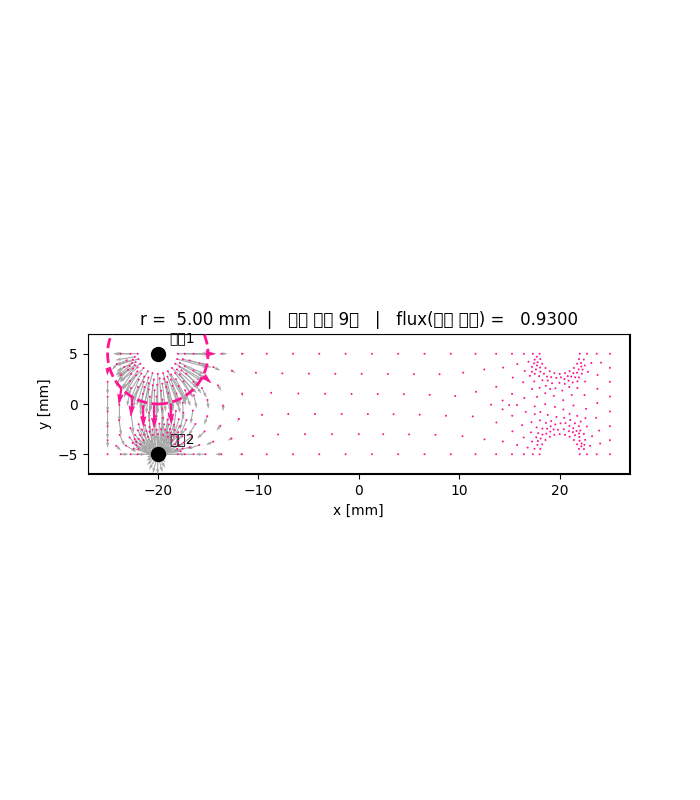

In [ ]:
fig, ax = plt.subplots(figsize=(7, 8))

# 팬텀 경계(사각형, 검정)
pad = 2
rect = mpatches.Rectangle((x.min() - pad, y.min() - pad),
                           x.max() - x.min() + 2 * pad, y.max() - y.min() + 2 * pad,
                           fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(rect)

# 전극(검정 원)
ax.plot(*elec1_xy, 'o', color='black', markersize=10, zorder=5)
ax.plot(*elec2_xy, 'o', color='black', markersize=10, zorder=5)
ax.annotate('전극1', elec1_xy, textcoords="offset points", xytext=(8, 8))
ax.annotate('전극2', elec2_xy, textcoords="offset points", xytext=(8, 8))

# 전체 필드 화살표 (회색, 길이=세기, CSV 전체 노드)
quiv_all = ax.quiver(coords_sub[:, 0], coords_sub[:, 1],
                      Ef1_sub[:, 0], Ef1_sub[:, 1],
                      color='0.65', angles='xy', scale_units='xy',
                      scale=Emag_sub.max() / 4, width=0.002, zorder=2)

# 강조 화살표 (분홍) — quiv_all과 같은 고정 위치에 그리고, 선택 안 된 점은 U,V=0으로 숨김
# (matplotlib Quiver.set_UVC는 최초 배열 크기를 기준으로 검증하므로 개수 자체를 바꿀 수 없음 — 크기 고정 + 0으로 마스킹)
quiv_sel = ax.quiver(coords_sub[:, 0], coords_sub[:, 1],
                      np.zeros(len(coords_sub)), np.zeros(len(coords_sub)),
                      color='deeppink', angles='xy', scale_units='xy',
                      scale=Emag_sub.max() / 4, width=0.004, zorder=4)

# 폐곡선(원, 점선)
init_r = (R_MIN + R_MAX) / 2
circle = mpatches.Circle(CENTER, init_r, fill=False, edgecolor='deeppink',
                          linestyle='--', linewidth=2, zorder=3)
ax.add_patch(circle)

title_txt = ax.set_title("")
ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
ax.set_aspect('equal')
ax.set_xlim(x.min() - pad, x.max() + pad)
ax.set_ylim(y.min() - pad, y.max() + pad)


def redraw(r_target):
    flux, mask = compute_flux(r_target)
    circle.set_radius(r_target)

    U = np.zeros(len(coords_sub))
    V = np.zeros(len(coords_sub))
    if mask.sum() >= 3:
        U[mask] = Ef1_sub[mask, 0]
        V[mask] = Ef1_sub[mask, 1]
    quiv_sel.set_UVC(U, V)

    title_txt.set_text(f"r = {r_target:5.2f} mm   |   선택 노드 {mask.sum()}개   |   flux(전류 근사) = {flux:8.4f}")
    fig.canvas.draw_idle()


redraw(init_r)

slider = widgets.FloatSlider(value=init_r, min=R_MIN, max=R_MAX, step=(R_MAX - R_MIN) / 100,
                              description='반지름 r [mm]', continuous_update=True,
                              layout=widgets.Layout(width='500px'))
slider.observe(lambda change: redraw(change['new']), names='value')

display(slider)

### 참고

CSV의 모든 노드를 그리므로 mesh가 매우 조밀하면 렌더링이 느릴 수 있습니다 — 그럴 땐 `code4` 셀에서
`coords_sub`/`Ef1_sub`/`Emag_sub`에 서브샘플링을 다시 넣어 조절하세요.

flux 값이 반지름마다 정확히 일정한지 노드 수 기준으로 더 정밀하게 보려면 `efield_analysis.ipynb`의 7절(`flux_at_radius`)을 참고하세요.
